# Task 2: Predict Future Stock Prices 
Objective: Use historical stock data to predict the next day's closing price. Train a Linear Regression model, and compare actual vs predicted close prices.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

stock_symbol = 'NVDA'
start_date = '2024-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

stock_data = yf.download(stock_symbol, start=start_date, end=end_date, progress=False)
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.138569,49.264879,47.565921,49.213912,411254000
2024-01-03,47.539936,48.154558,47.291088,47.455988,320896000
2024-01-04,47.968681,48.470374,47.478979,47.737820,306535000
2024-01-05,49.067009,49.516735,48.276492,48.432399,415039000
2024-01-08,52.221077,52.243067,49.448773,49.481754,642510000


In [2]:
data = stock_data.copy()
feature_columns = ['Open', 'High', 'Low', 'Volume']

data['Next_Close'] = data['Close'].shift(-1)
model_data = data.dropna().reset_index()

X = model_data[feature_columns]
y = model_data['Next_Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(model_data.head())

Training samples: 481
Testing samples: 121
Price        Date      Close       High        Low       Open     Volume  \
Ticker                  NVDA       NVDA       NVDA       NVDA       NVDA   
0      2024-01-02  48.138569  49.264879  47.565921  49.213912  411254000   
1      2024-01-03  47.539936  48.154558  47.291088  47.455988  320896000   
2      2024-01-04  47.968681  48.470374  47.478979  47.737820  306535000   
3      2024-01-05  49.067009  49.516735  48.276492  48.432399  415039000   
4      2024-01-08  52.221077  52.243067  49.448773  49.481754  642510000   

Price  Next_Close  
Ticker             
0       47.539936  
1       47.968681  
2       49.067009  
3       52.221077  
4       53.107536  


In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train R^2: 0.9868
Test R^2: 0.9014
Train RMSE: 4.0834
Test RMSE: 4.4844


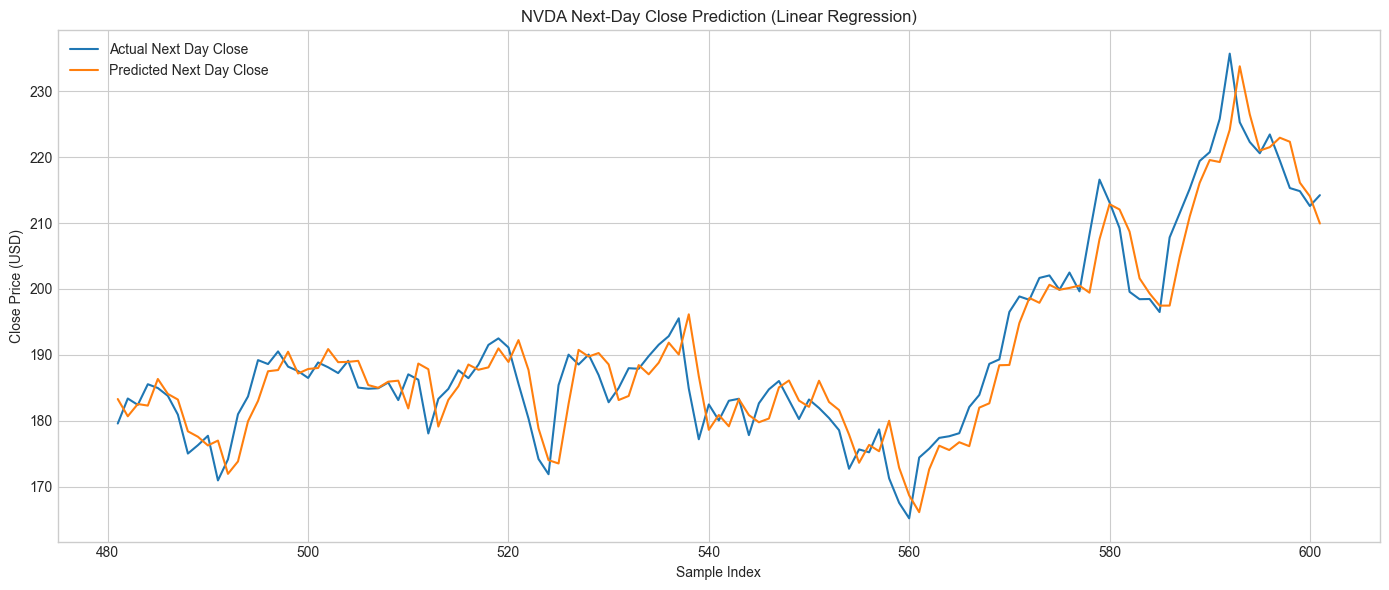

Predicted next day's close for NVDA using most recent features: $209.95


In [4]:
results = pd.DataFrame({
    'Actual_Next_Close': y_test.values,
    'Predicted_Next_Close': test_predictions
}, index=X_test.index)

plt.figure(figsize=(14, 6))
plt.plot(results.index, results['Actual_Next_Close'], label='Actual Next Day Close', color='tab:blue', linewidth=1.5)
plt.plot(results.index, results['Predicted_Next_Close'], label='Predicted Next Day Close', color='tab:orange', linewidth=1.5)
plt.title(f'{stock_symbol} Next-Day Close Prediction (Linear Regression)')
plt.xlabel('Sample Index')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

prediction_index = model_data.index[-1]
latest_features = model_data[feature_columns].iloc[-1]
next_day_prediction = model.predict(latest_features.to_frame().T)[0]

print(f"Predicted next day's close for {stock_symbol} using most recent features: ${next_day_prediction:.2f}")